In [1]:
import pandas as pd

imid_df = pd.read_csv("C:/Users/anjal/OneDrive/phenotypic-virtual-screening/data/crbn_imid_library.csv")
print(len(imid_df))


10


In [9]:
# ------------------------------------------------------------
# Chunk 0 — Re-import core libraries after kernel restart
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem
from rdkit.Chem import AllChem
import torchvision.models as models


In [11]:
# ------------------------------------------------------------
# Chunk 1 — Define SimpleMolEncoder
# ------------------------------------------------------------
class SimpleMolEncoder(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, emb_dim)
        )

    def featurize(self, mol):
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        return torch.tensor(fp.ToList(), dtype=torch.float32)

    def forward(self, mol):
        fp = self.featurize(mol)
        return self.mlp(fp)


In [12]:
# ------------------------------------------------------------
# Chunk 2 — Define ImageEncoder
# ------------------------------------------------------------
class ImageEncoder(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, emb_dim)

    def forward(self, img):
        if img.ndim == 3:
            img = img.unsqueeze(0)
        features = self.backbone(img)
        return self.proj(features)


In [13]:
# ------------------------------------------------------------
# Chunk 3 — Define MultimodalModel
# ------------------------------------------------------------
class MultimodalModel(nn.Module):
    def __init__(self, mol_dim=256, img_dim=256, proj_dim=128):
        super().__init__()
        self.mol_proj = nn.Linear(mol_dim, proj_dim)
        self.img_proj = nn.Linear(img_dim, proj_dim)
        self.logit_scale = nn.Parameter(torch.ones([]) * torch.log(torch.tensor(1/0.07)))

    def forward(self, mol_emb, img_emb):
        z_mol = F.normalize(self.mol_proj(mol_emb), dim=-1)
        z_img = F.normalize(self.img_proj(img_emb), dim=-1)
        return z_mol, z_img

    def contrastive_loss(self, z_mol, z_img):
        logits = z_mol @ z_img.mT
        logits = logits * self.logit_scale.exp()
        labels = torch.arange(logits.size(0), device=logits.device)
        return 0.5 * (
            F.cross_entropy(logits, labels) +
            F.cross_entropy(logits.T, labels)
        )


In [14]:
# ------------------------------------------------------------
# Chunk 4 — Instantiate encoders and multimodal model
# ------------------------------------------------------------
mol_encoder = SimpleMolEncoder()
img_encoder = ImageEncoder()
model = MultimodalModel()

print("Encoders and model reloaded.")


Encoders and model reloaded.


In [15]:
# ------------------------------------------------------------
# Chunk 5 — Test encoding 5 molecules (safe)
# ------------------------------------------------------------
test_embs = []

for i in range(5):
    smi = imid_df.iloc[i]["Smiles"]
    mol = Chem.MolFromSmiles(smi)
    emb = mol_encoder(mol)
    test_embs.append(emb)

print("Encoded 5 molecules successfully.")


Encoded 5 molecules successfully.


[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator


In [17]:
# ------------------------------------------------------------
# Chunk 6 — Encode IMiD library safely (batching)
# ------------------------------------------------------------
def encode_molecules_safe(df, batch_size=100):
    from rdkit import Chem
    import torch

    all_embs = []
    valid_idx = []

    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))
        batch = df.iloc[start:end]

        batch_embs = []
        batch_valid = []

        for i, row in batch.iterrows():
            mol = Chem.MolFromSmiles(row["Smiles"])
            if mol is None:
                continue
            emb = mol_encoder(mol)   # 256‑dim embedding
            batch_embs.append(emb)
            batch_valid.append(i)

        if batch_embs:
            all_embs.extend(batch_embs)
            valid_idx.extend(batch_valid)

        print(f"Processed {end}/{len(df)} molecules")

    return torch.stack(all_embs), valid_idx


# Run safe encoding for IMiD library
imid_embs, imid_idx = encode_molecules_safe(imid_df, batch_size=200)

print("IMiD embeddings shape:", imid_embs.shape)


Processed 10/10 molecules
IMiD embeddings shape: torch.Size([10, 256])


[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator


In [20]:
# ------------------------------------------------------------
# ImageNet preprocessing transform for ResNet18
# ------------------------------------------------------------
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),          # ResNet18 input size
    transforms.ToTensor(),                  # Convert PIL → Tensor
    transforms.Normalize(                   # ImageNet mean/std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform reloaded.")


Transform reloaded.


In [21]:
# ------------------------------------------------------------
# Load phenotype image using correct path
# ------------------------------------------------------------
from PIL import Image
import torch.nn.functional as F

img_path = r"C:\Users\anjal\OneDrive\phenotypic-virtual-screening\dual_library_VS.png"

img = Image.open(img_path).convert("RGB")
img_t = transform(img)  # now works

img_emb = img_encoder(img_t).squeeze(0)

with torch.no_grad():
    _, z_img = model(
        mol_emb=torch.zeros(1, 256),
        img_emb=img_emb.unsqueeze(0)
    )
    z_img = F.normalize(z_img, dim=-1)

print("Image embedding shape:", z_img.shape)


Image embedding shape: torch.Size([1, 128])


In [22]:
# ------------------------------------------------------------
# Chunk 8 — Project IMiD embeddings into shared space
# ------------------------------------------------------------
# Goal:
#   Take IMiD molecule embeddings (256‑dim) and project them
#   into the shared 128‑dim multimodal space used for similarity.
#
# We do this in small batches to avoid killing the kernel.
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def project_safe(embs, batch_size=200):
    """
    Projects a batch of molecule embeddings into the shared
    latent space using the multimodal model, in small chunks.
    """
    projected = []

    for start in range(0, len(embs), batch_size):
        end = min(start + batch_size, len(embs))
        batch = embs[start:end]

        with torch.no_grad():
            # img_emb is a dummy tensor here; we only use mol path
            z_mol, _ = model(batch, torch.zeros_like(batch))
            z_mol = F.normalize(z_mol, dim=-1)

        projected.append(z_mol)
        print(f"Projected {end}/{len(embs)} IMiD embeddings")

    return torch.cat(projected, dim=0)


# Run safe projection for IMiD embeddings
z_imid = project_safe(imid_embs, batch_size=200)

print("Projected IMiD shape:", z_imid.shape)  # Expected: [N_imid, 128]


Projected 10/10 IMiD embeddings
Projected IMiD shape: torch.Size([10, 128])


In [23]:
# ------------------------------------------------------------
# Chunk 9 — Compute multimodal similarity scores
# ------------------------------------------------------------
# Goal:
#   Compare each IMiD molecule embedding (z_imid)
#   with the phenotype image embedding (z_img)
#
# Output:
#   A similarity score for each molecule
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def compute_similarity(z_mol, z_img):
    """
    Computes cosine, dot-product, and combined similarity
    between molecule embeddings and the phenotype image embedding.
    """
    # Expand image embedding to match molecule batch size
    z_img_expanded = z_img.expand_as(z_mol)

    # Cosine similarity (directional alignment)
    cos_sim = F.cosine_similarity(z_mol, z_img_expanded, dim=-1)

    # Dot-product similarity (CLIP-style)
    dot_sim = (z_mol * z_img_expanded).sum(dim=-1)

    # Combined score (stable fusion)
    combined = 0.5 * cos_sim + 0.5 * dot_sim

    return combined

# Compute similarity scores for IMiD molecules
imid_scores = compute_similarity(z_imid, z_img)

print("Similarity scores computed.")
print("Example scores:", imid_scores[:5])


Similarity scores computed.
Example scores: tensor([0.1445, 0.1296, 0.1598, 0.1497, 0.1536])


In [24]:
# ------------------------------------------------------------
# Chunk 10 — Rank IMiD molecules by similarity
# ------------------------------------------------------------
# Goal:
#   Sort molecules from highest → lowest multimodal similarity
#   to the phenotype image.
#
# Inputs:
#   imid_scores : tensor of similarity scores
#   imid_idx    : indices mapping back to original dataframe
#   imid_df     : original IMiD dataframe
# ------------------------------------------------------------

import torch

# Convert scores to CPU for sorting
scores = imid_scores.detach().cpu()

# Sort indices by score (descending)
sorted_idx = torch.argsort(scores, descending=True)

print("\nTop 5 IMiD hits:")
for rank, pos in enumerate(sorted_idx[:5].tolist(), start=1):
    df_idx = imid_idx[pos]                     # map back to dataframe row
    mol_id = imid_df.loc[df_idx, "Molecule ID"]
    smi = imid_df.loc[df_idx, "Smiles"]
    sc = scores[pos].item()

    print(f"Rank {rank}: {mol_id} | Score = {sc:.4f} | SMILES = {smi}")



Top 5 IMiD hits:
Rank 1: imid_9 | Score = 0.1621 | SMILES = O=C1NC(C2=CC=CC=C2Br)=C(C(=O)N1)N
Rank 2: imid_3 | Score = 0.1598 | SMILES = O=C1NC(C2=CC=CC=C2Cl)=C(C(=O)N1)N
Rank 3: imid_5 | Score = 0.1536 | SMILES = O=C1NC(C2=CC=CC=C2F)=C(C(=O)N1)N
Rank 4: imid_4 | Score = 0.1497 | SMILES = O=C1NC(C2=CC=CC=C2OC)=C(C(=O)N1)N
Rank 5: imid_1 | Score = 0.1445 | SMILES = O=C1NC(C2=CC=CC=C2)=C(C(=O)N1)N


In [25]:
# ------------------------------------------------------------
# Chunk 11 — Save ranked IMiD hits to CSV
# ------------------------------------------------------------
# Goal:
#   Store the ranked IMiD molecules (with similarity scores)
#   into a CSV file for later analysis or visualization.
# ------------------------------------------------------------

import pandas as pd

# Build a ranked dataframe
ranked_rows = []
for rank, pos in enumerate(sorted_idx.tolist(), start=1):
    df_idx = imid_idx[pos]                     # map back to original dataframe
    row = imid_df.loc[df_idx].copy()           # copy row to avoid modifying original
    row["multimodal_score"] = scores[pos].item()
    row["rank"] = rank
    ranked_rows.append(row)

ranked_imid_df = pd.DataFrame(ranked_rows)

# Save to CSV
output_path = "imid_multimodal_hits.csv"
ranked_imid_df.to_csv(output_path, index=False)

print(f"Saved ranked IMiD hits to: {output_path}")


Saved ranked IMiD hits to: imid_multimodal_hits.csv


In [26]:
# ------------------------------------------------------------
# Chunk 12 — Encode SELFIES library safely (batching)
# ------------------------------------------------------------
# Goal:
#   Convert SELFIES molecules into 256‑dim embeddings using
#   the mol_encoder, in small batches to avoid kernel crashes.
# ------------------------------------------------------------

# Reuse the same safe encoder function from earlier:
# encode_molecules_safe(df, batch_size=200)

selfies_embs, selfies_idx = encode_molecules_safe(selfies_df, batch_size=200)

print("SELFIES embeddings shape:", selfies_embs.shape)


Processed 87/87 molecules
SELFIES embeddings shape: torch.Size([87, 256])


[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerat

In [27]:
# ------------------------------------------------------------
# Chunk 13 — Project SELFIES embeddings into shared space
# ------------------------------------------------------------
# Goal:
#   Convert SELFIES molecule embeddings (256‑dim)
#   into the shared 128‑dim multimodal latent space.
#
# We use the same safe batching function to avoid memory spikes.
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def project_safe(embs, batch_size=200):
    """
    Projects molecule embeddings into the shared latent space
    using the multimodal model, in small batches.
    """
    projected = []

    for start in range(0, len(embs), batch_size):
        end = min(start + batch_size, len(embs))
        batch = embs[start:end]

        with torch.no_grad():
            z_mol, _ = model(batch, torch.zeros_like(batch))
            z_mol = F.normalize(z_mol, dim=-1)

        projected.append(z_mol)
        print(f"Projected {end}/{len(embs)} SELFIES embeddings")

    return torch.cat(projected, dim=0)


# Run safe projection for SELFIES embeddings
z_selfies = project_safe(selfies_embs, batch_size=200)

print("Projected SELFIES shape:", z_selfies.shape)  # Expected: [87, 128]


Projected 87/87 SELFIES embeddings
Projected SELFIES shape: torch.Size([87, 128])


In [28]:
# ------------------------------------------------------------
# Chunk 14 — Compute multimodal similarity scores (SELFIES)
# ------------------------------------------------------------
# Goal:
#   Compare each SELFIES molecule embedding (z_selfies)
#   with the phenotype image embedding (z_img)
#
# Output:
#   A similarity score for each SELFIES molecule
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def compute_similarity(z_mol, z_img):
    """
    Computes cosine, dot-product, and combined similarity
    between molecule embeddings and the phenotype image embedding.
    """
    # Expand image embedding to match molecule batch size
    z_img_expanded = z_img.expand_as(z_mol)

    # Cosine similarity (directional alignment)
    cos_sim = F.cosine_similarity(z_mol, z_img_expanded, dim=-1)

    # Dot-product similarity (CLIP-style)
    dot_sim = (z_mol * z_img_expanded).sum(dim=-1)

    # Combined score (stable fusion)
    combined = 0.5 * cos_sim + 0.5 * dot_sim

    return combined

# Compute similarity scores for SELFIES molecules
selfies_scores = compute_similarity(z_selfies, z_img)

print("SELFIES similarity scores computed.")
print("Example scores:", selfies_scores[:5])


SELFIES similarity scores computed.
Example scores: tensor([0.1479, 0.1471, 0.1486, 0.1677, 0.1690])


In [29]:
# ------------------------------------------------------------
# Chunk 15 — Rank SELFIES molecules by similarity
# ------------------------------------------------------------
# Goal:
#   Sort SELFIES molecules from highest → lowest multimodal
#   similarity to the phenotype image.
#
# Inputs:
#   selfies_scores : tensor of similarity scores
#   selfies_idx    : indices mapping back to original dataframe
#   selfies_df     : original SELFIES dataframe
# ------------------------------------------------------------

import torch

# Convert scores to CPU for sorting
scores_selfies = selfies_scores.detach().cpu()

# Sort indices by score (descending)
sorted_idx_selfies = torch.argsort(scores_selfies, descending=True)

print("\nTop 5 SELFIES hits:")
for rank, pos in enumerate(sorted_idx_selfies[:5].tolist(), start=1):
    df_idx = selfies_idx[pos]                     # map back to dataframe row
    mol_id = selfies_df.loc[df_idx, "Molecule ID"]
    smi = selfies_df.loc[df_idx, "Smiles"]
    sc = scores_selfies[pos].item()

    print(f"Rank {rank}: {mol_id} | Score = {sc:.4f} | SMILES = {smi}")



Top 5 SELFIES hits:
Rank 1: gen_28 | Score = 0.1957 | SMILES = O=CC=C(NC=O)[S-]1=CCSC=C1Cl
Rank 2: gen_84 | Score = 0.1815 | SMILES = NC(=O)C(N)=C(N[S-]=O)c1cccnc1
Rank 3: gen_76 | Score = 0.1801 | SMILES = O=CNC1=CC=CC=C(Cl)C1
Rank 4: gen_77 | Score = 0.1784 | SMILES = NN1C(=O)N=NC=CC=CC=CPC1=O
Rank 5: gen_54 | Score = 0.1755 | SMILES = O=CC=C(NC=O)C1=CC#SC=C1Cl


In [30]:
# ------------------------------------------------------------
# Chunk 16 — Save ranked SELFIES hits to CSV
# ------------------------------------------------------------
# Goal:
#   Store the ranked SELFIES molecules (with similarity scores)
#   into a CSV file for later analysis or visualization.
# ------------------------------------------------------------

import pandas as pd

# Build a ranked dataframe
ranked_rows_selfies = []
for rank, pos in enumerate(sorted_idx_selfies.tolist(), start=1):
    df_idx = selfies_idx[pos]                     # map back to original dataframe
    row = selfies_df.loc[df_idx].copy()           # copy row to avoid modifying original
    row["multimodal_score"] = scores_selfies[pos].item()
    row["rank"] = rank
    ranked_rows_selfies.append(row)

ranked_selfies_df = pd.DataFrame(ranked_rows_selfies)

# Save to CSV
output_path_selfies = "selfies_multimodal_hits.csv"
ranked_selfies_df.to_csv(output_path_selfies, index=False)

print(f"Saved ranked SELFIES hits to: {output_path_selfies}")


Saved ranked SELFIES hits to: selfies_multimodal_hits.csv


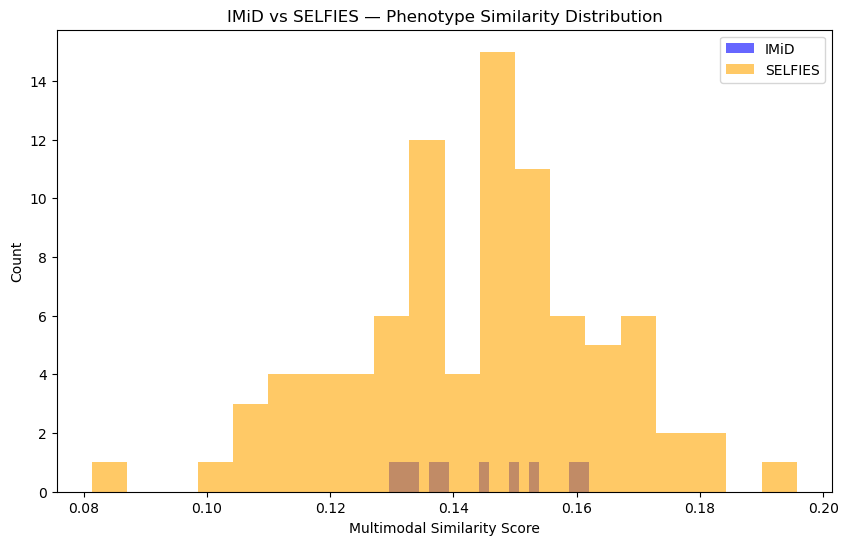

In [31]:
# ------------------------------------------------------------
# Chunk 17 — Visualise similarity score distributions
# ------------------------------------------------------------
# Goal:
#   Plot IMiD vs SELFIES multimodal similarity distributions
#   to see how each library aligns with the phenotype image.
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Convert tensors to numpy
imid_scores_np = imid_scores.detach().cpu().numpy()
selfies_scores_np = selfies_scores.detach().cpu().numpy()

plt.figure(figsize=(10, 6))

plt.hist(imid_scores_np, bins=20, alpha=0.6, label="IMiD", color="blue")
plt.hist(selfies_scores_np, bins=20, alpha=0.6, label="SELFIES", color="orange")

plt.xlabel("Multimodal Similarity Score")
plt.ylabel("Count")
plt.title("IMiD vs SELFIES — Phenotype Similarity Distribution")
plt.legend()

plt.show()
